# <center>**Importing Essential Libraries and Defining Dataset Paths**</center>

In [1]:
# Standard libraries
import os
import re
import copy
import time
import random
from pathlib import Path
from collections import Counter, defaultdict
import shutil
import math


# Data handling
import pandas as pd
import numpy as np
from scipy.stats import skew
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pillow_heif

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.v2 as v2

# Enable HEIF/HEIC support
pillow_heif.register_heif_opener()

# ----------------------------
# Environment logging
# ----------------------------
print("=== Environment Info ===")
print(f"OS: {os.name}")
print(f"Python version: {os.sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

if torch.backends.mps.is_available():
    print("Apple GPU (MPS) available: Yes")
else:
    print("Apple GPU (MPS) available: No")

=== Environment Info ===
OS: posix
Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
PyTorch version: 2.5.1
Torchvision version: 0.20.1
Numpy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.9.2
Seaborn version: 0.13.2
Apple GPU (MPS) available: Yes


In [95]:
import os
from pathlib import Path
from dotenv import load_dotenv

CONFIG_FILE = Path.home() / ".wadidegla.env"
load_dotenv(CONFIG_FILE, override=False)

DATA_DIR = Path(os.environ["WADIDEGLA_DATA_DIR"])

# <center>**Utility Functions for Model Training & Evaluation**</center>

In [42]:
def load_and_unfreeze_classifier(num_classes, models_to_load=('mobilenet_v2', 'resnet18', 'vgg16')):
    loaded_models = {}

    for model_name in models_to_load:
        if model_name == 'mobilenet_v2':
            model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
            # Freeze all features
            for param in model.features.parameters():
                param.requires_grad = False
            # Replace classifier
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
            # Unfreeze classifier
            for param in model.classifier.parameters():
                param.requires_grad = True

        elif model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            # Freeze all parameters
            for param in model.parameters():
                param.requires_grad = False
            # Replace final FC layer
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, num_classes)
            # Unfreeze classifier (fc)
            for param in model.fc.parameters():
                param.requires_grad = True

        elif model_name == 'vgg16':
            model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
            # Freeze all feature extractor parameters
            for param in model.features.parameters():
                param.requires_grad = False
            # Freeze all classifier layers first
            for param in model.classifier.parameters():
                param.requires_grad = False
            # Replace and unfreeze only the last classifier layer
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
            for param in model.classifier[-1].parameters():
                param.requires_grad = True

        else:
            raise ValueError(f"Unsupported model name: {model_name}")

        # ---- Summary ----
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        frozen_params = total_params - trainable_params

        print(f"\n✅ {model_name.upper()} Summary:")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable parameters: {trainable_params:,}")
        print(f"   Frozen parameters: {frozen_params:,}")

        if model_name == 'mobilenet_v2':
            print("   🔸 Unfrozen: classifier (entire head)")
        elif model_name == 'resnet18':
            print("   🔸 Unfrozen: fc (final fully connected layer)")
        elif model_name == 'vgg16':
            print("   🔸 Unfrozen: classifier[-1] (final linear layer only)")

        loaded_models[model_name] = model

    return loaded_models

In [43]:
def train_model(model, train_loader, criterion, optimizer, class_names, epoch_num=1, log_interval=100):
    start_time = time.time()  # Start tracking time
    device = torch.device("cuda" if torch.cuda.is_available() else "mps")  # Use GPU if available on Mac

    # Dictionary to store per-class metrics
    class_metrics = defaultdict(lambda: {"correct": 0, "total": 0, "y_true": [], "y_pred": []})

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    epoch_start_time = time.time()  # Track epoch time

    for batch_idx, (images, labels) in enumerate(train_loader, 1):  # Start index from 1
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute accuracy
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        accuracy = 100 * correct / total

        # Store predictions for per-class metrics
        for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
            class_metrics[label]["correct"] += (label == pred)
            class_metrics[label]["total"] += 1
            class_metrics[label]["y_true"].append(label)
            class_metrics[label]["y_pred"].append(pred)

        # Print loss and accuracy every 100 batches
        if batch_idx % log_interval == 0:
            elapsed_time = (time.time() - start_time)/60
            print(f"Epoch {epoch_num}, Batch {batch_idx}, Loss: {running_loss/batch_idx:.4f}, "
                  f"Accuracy: {accuracy:.2f}%, Time Passed: {elapsed_time:.2f}m")

    epoch_time = (time.time() - epoch_start_time)/60
    print(f"Epoch {epoch_num} Completed - Average Loss: {running_loss/len(train_loader):.4f}, "
          f"Accuracy: {accuracy:.2f}%, Epoch Time: {epoch_time:.2f}m")
    overall_accuracy = 100 * correct / total

    total_time = (time.time() - start_time)/60
    print(f"Training Complete Epoch {epoch_num} - Total Time: {total_time:.2f}m")

    # Calculate per-class accuracy, precision, recall, and F1-score
    all_y_true = []
    all_y_pred = []
    
    for class_idx in sorted(class_metrics.keys()):
        all_y_true.extend(class_metrics[class_idx]["y_true"])
        all_y_pred.extend(class_metrics[class_idx]["y_pred"])
    
    # Compute per-class precision, recall, and F1-score
    unique_classes = sorted(set(all_y_true))  # Get all unique classes
    per_class_metrics = {
        "precision": precision_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0),
        "recall": recall_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0),
        "f1_score": f1_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0)
    }

    # Store per-class results in alignment with unique_classes
    class_results = []
    for class_idx in unique_classes:
        class_results.append([
            class_names[class_idx],
            per_class_metrics["precision"][unique_classes.index(class_idx)]*100,
            per_class_metrics["recall"][unique_classes.index(class_idx)]*100,
            per_class_metrics["f1_score"][unique_classes.index(class_idx)]*100
        ])

    # Create a DataFrame with per-class accuracy, precision, recall, and F1-score
    df_results = pd.DataFrame(class_results, columns=["Species", "Precision", "Recall", "F1-score"])

    # Append overall metrics (Macro) as the last row
    macro_precision = per_class_metrics["precision"].mean()*100
    macro_recall = per_class_metrics["recall"].mean()*100
    macro_f1 = per_class_metrics["f1_score"].mean()*100

    df_results.loc[len(df_results)] = ["Average Performance (Macro)", macro_precision, macro_recall, macro_f1]

    df_results['Epoch'] = epoch_num
    avg_loss = running_loss / len(train_loader)

    return {
    'model': model,
    'optimizer': optimizer,
    'metrics_df': df_results,
    'overall_accuracy': overall_accuracy,
    'total_loss': running_loss,
    'avg_loss': avg_loss,
    'epoch_time': epoch_time
            }

In [44]:
def evaluate_model(model, val_loader, criterion, class_names, epoch_num=1, log_interval=100):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "mps")
    
    start_time = time.time()  # Track evaluation time

    # Dictionary to store per-class metrics
    class_metrics = defaultdict(lambda: {"correct": 0, "total": 0, "y_true": [], "y_pred": []})
    all_y_true = []
    all_y_pred = []
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader, 1):  # Start index from 1
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(preds.cpu().numpy())

            # Compute accuracy
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            accuracy = 100 * correct / total

            # Store per-class metrics
            for label, pred in zip(labels.cpu().numpy(), preds.cpu().numpy()):
                class_metrics[label]["correct"] += (label == pred)
                class_metrics[label]["total"] += 1
                class_metrics[label]["y_true"].append(label)
                class_metrics[label]["y_pred"].append(pred)

            # Print progress every 100 batches
            if batch_idx % log_interval == 0:
                elapsed_time = (time.time() - start_time)/60
                avg_loss = running_loss / batch_idx
                print(f"Batch {batch_idx}, Loss: {avg_loss:.4f}, "
                      f"Accuracy: {accuracy:.2f}%, Time Passed: {elapsed_time:.2f}m")

    total_time = (time.time() - start_time)/60
    avg_loss = running_loss / len(val_loader)
    print(f"Evaluation Complete - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%, Total Time: {total_time:.2f}m")
    overall_accuracy = 100 * correct / total

    # Compute per-class accuracy
    class_results = []
    for class_idx in sorted(class_metrics.keys()):
        metrics = class_metrics[class_idx]
        class_results.append([class_names[class_idx]])

    # Compute per-class precision, recall, and F1-score
    unique_classes = sorted(set(all_y_true))  # Get all unique classes
    per_class_metrics = {
        "precision": precision_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0),
        "recall": recall_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0),
        "f1_score": f1_score(all_y_true, all_y_pred, labels=unique_classes, average=None, zero_division=0)
    }

    # Store per-class metrics
    for idx, class_label in enumerate(unique_classes):
        class_results[idx].extend([
            per_class_metrics["precision"][idx],
            per_class_metrics["recall"][idx],
            per_class_metrics["f1_score"][idx]
        ])

    # Create a DataFrame with per-class accuracy, precision, recall, and F1-score
    df_results = pd.DataFrame(class_results, columns=["Species", "Precision", "Recall", "F1-score"])

    # Append overall metrics (Macro) as the last row
    macro_precision = per_class_metrics["precision"].mean()
    macro_recall = per_class_metrics["recall"].mean()
    macro_f1 = per_class_metrics["f1_score"].mean()

    df_results.loc[len(df_results)] = ["Average Performance (Macro)", macro_precision, macro_recall, macro_f1]

    df_results['Epoch'] = epoch_num
    return {
    'metrics_df': df_results,
    'overall_accuracy': overall_accuracy,
    'avg_loss': avg_loss,
    'epoch_time': total_time
            }

In [45]:
def create_performance_summary(df, micro_accuracy, avg_loss, model_name, train_val, class_weights, time_taken, epoch):
    # Extract macro metrics from the last row
    
    macro_row = df[df['Species'] == 'Average Performance (Macro)']
    precision_macro = macro_row['Precision'].values[0]
    recall_macro = macro_row['Recall'].values[0]
    f1_macro = macro_row['F1-score'].values[0]


    # Exclude the last row to analyze per-class accuracies
    class_accuracies = df[df['Species'] != 'Average Performance (Macro)'].copy()

    # Identify best and worst class based on accuracy
    best_class = class_accuracies.loc[class_accuracies['F1-score'].idxmax(), 'Species']
    worst_class = class_accuracies.loc[class_accuracies['F1-score'].idxmin(), 'Species']

    # Compute the median accuracy and find the nearest class
    median_f1_macro = class_accuracies['F1-score'].median()
    class_accuracies['Abs_Diff'] = (class_accuracies['F1-score'] - median_f1_macro).abs()
    median_class = class_accuracies.loc[class_accuracies['Abs_Diff'].idxmin(), 'Species']

    # Compute the number of classes above micro and macro accuracy averages
    num_classes_above_f1_macro_avg = (class_accuracies['F1-score'] > f1_macro).sum()
    num_classes_above_f1_macro_median = (class_accuracies['F1-score'] > median_f1_macro).sum()

    # Create the final summary DataFrame
    performance_summary = pd.DataFrame({
        "Model": [model_name],
        "Dataset Split": [train_val],
        "Accuracy (micro)": [micro_accuracy],
        "Precision (macro)": [precision_macro],
        "Recall (macro)": [recall_macro],
        "F1 (macro)": [f1_macro],
        "Loss": [avg_loss],
        "Class_weights": [class_weights],
        "Best_class": [best_class],
        "Median_class": [median_class],
        "Worst_class": [worst_class],
        "num_classes_above_f1_macro_avg": [num_classes_above_f1_macro_avg],
        "num_classes_above_f1_macro_median": [num_classes_above_f1_macro_median],
        "Time Taken (mins)": [time_taken],
        "Epoch": [epoch]
    })


    return performance_summary

In [46]:
def train_and_evaluate_model(
    model: nn.Module,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    class_names,
    start_epoch: int,
    end_epoch: int,
    model_name: str,
    save_dir: str,
    class_weights: str,
    log_interval: int,
    evaluate = True
):
    """
    Train and evaluate a model, storing per-epoch metrics, summaries, and states.

    Returns:
        dict: {
            'epoch_states': {epoch_num: {'model_state': ..., 'optimizer_state': ..., 'train_metrics': ..., 'val_metrics': ...}},
            'train_results_df': pd.DataFrame,
            'train_summary_df': pd.DataFrame,
            'val_results_df': pd.DataFrame,
            'val_summary_df': pd.DataFrame
        }
    """
    device = torch.device("mps")
    model.to(device)  # Move model to MPS

    # Initialize storage
    epoch_states = {}
    train_results_list, train_summary_list = [], []
    val_results_list, val_summary_list = [], []


    for epoch in range(start_epoch, end_epoch + 1):
        print(f"\n🚀 Epoch {epoch} - Training Started...\n")
        
        # ---- Training ----
        training_result = train_model(
            model, train_loader, criterion, optimizer, class_names, epoch_num=epoch, log_interval=log_interval
        )
        train_summary = create_performance_summary(
            training_result['metrics_df'],
            training_result['overall_accuracy'],
            training_result['avg_loss'],
            model_name=model_name,
            train_val='Train',
            class_weights=class_weights,
            time_taken=training_result['epoch_time'],
            epoch = epoch
        )
        
        train_results_list.append(training_result['metrics_df'])
        train_summary_list.append(train_summary)
        if evaluate:

            print(f"\n✅ Epoch {epoch} - Training Completed. Starting Evaluation...\n")
    
            # ---- Validation ----
            val_result = evaluate_model(
                model, val_loader, criterion, class_names, epoch_num=epoch, log_interval=log_interval
            )
            val_summary = create_performance_summary(
                val_result['metrics_df'],
                val_result['overall_accuracy'],
                val_result['avg_loss'],
                model_name=model_name,
                train_val='Validation',
                class_weights=class_weights,
                time_taken=val_result['epoch_time'],
                epoch = epoch
            )
    
            val_results_list.append(val_result['metrics_df'])
            val_summary_list.append(val_summary)
            print(f"\n📊 Epoch {epoch} - Evaluation Completed.\n")

        else:
            print(f"\n✅ Epoch {epoch} - Training Completed (No Evaluation).\n")

        # ---- Save model + optimizer state for this epoch ----
        if epoch == end_epoch:
            epoch_states[epoch] = {
                'model_state_dict': copy.deepcopy(model.state_dict()),
                'optimizer_state_dict': copy.deepcopy(optimizer.state_dict())
            }

        

    # ---- Combine DataFrames ----
    train_results_df = pd.concat(train_results_list, ignore_index=True)
    train_summary_df = pd.concat(train_summary_list, ignore_index=True)
    if evaluate:
        val_results_df = pd.concat(val_results_list, ignore_index=True)
        val_summary_df = pd.concat(val_summary_list, ignore_index=True)

    else:
        val_results_df, val_summary_df = None, None

    # Optionally save to CSV (you can remove if not needed)
    train_results_df.to_csv(f"{save_dir}/{model_name}_train_results{start_epoch}_{end_epoch}.csv", index=False)
    train_summary_df.to_csv(f"{save_dir}/{model_name}_train_summary{start_epoch}_{end_epoch}.csv", index=False)
    if evaluate:
        val_results_df.to_csv(f"{save_dir}/{model_name}_val_results{start_epoch}_{end_epoch}.csv", index=False)
        val_summary_df.to_csv(f"{save_dir}/{model_name}_val_summary{start_epoch}_{end_epoch}.csv", index=False)

    return epoch_states, {
        'train_results_df': train_results_df,
        'train_summary_df': train_summary_df,
        'val_results_df': val_results_df,
        'val_summary_df': val_summary_df
    }

In [47]:
def set_seed(seed: int, deterministic: bool = True):
    """
    Initialize all RNG seeds for reproducibility on Apple Silicon M1.
    Optimized for MPS backend.

    Returns:
        start_rng_state (dict): RNG states captured immediately after seeding.
        generator (torch.Generator): Torch generator initialized with the same seed.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    if deterministic:
        torch.use_deterministic_algorithms(True)

    generator = torch.Generator()
    generator.manual_seed(seed)

    rng_state = {
        'seed': seed,
        'rng_python': random.getstate(),
        'rng_numpy': np.random.get_state(),
        'rng_torch': torch.get_rng_state(),
        'rng_torch_mps': torch.mps.get_rng_state() if torch.backends.mps.is_available() else None,
        'deterministic': deterministic,
        'generator_state': generator.get_state()
    }
    print(f"✅ Random seed set to {seed} (MPS available: {torch.backends.mps.is_available()})")
    return rng_state, generator

In [48]:
def get_rng_state(seed: int, generator: torch.Generator, deterministic: bool = True):
    """
    Capture the CURRENT RNG states for Python, NumPy, and PyTorch (CPU + MPS if available).

    Returns:
        (dict, torch.Generator): RNG state dict and the generator.
    """
    rng_state = {
        'seed': seed,
        'rng_python': random.getstate(),
        'rng_numpy': np.random.get_state(),
        'rng_torch': torch.get_rng_state(),
        'rng_torch_mps': torch.mps.get_rng_state() if torch.backends.mps.is_available() else None,
        'deterministic': deterministic,
        'generator_state': generator.get_state()
    }
    return rng_state, generator

In [49]:
def manage_rng_state(path: str, mode: str, seed: int = None, generator: torch.Generator = None, deterministic: bool = True):
    """
    Save or load RNG state for Python, NumPy, and PyTorch (CPU + MPS).

    Returns:
        (dict, torch.Generator): RNG state dict and the generator.
    """
    if mode == 'load':
        rng_state = joblib.load(path)

        random.setstate(rng_state['rng_python'])
        np.random.set_state(rng_state['rng_numpy'])
        torch.set_rng_state(rng_state['rng_torch'])
        if torch.backends.mps.is_available() and rng_state.get('rng_torch_mps') is not None:
            torch.mps.set_rng_state(rng_state['rng_torch_mps'])
        torch.use_deterministic_algorithms(rng_state.get('deterministic', False))

        generator = torch.Generator()
        if 'generator_state' in rng_state:
            generator.set_state(rng_state['generator_state'])
        elif seed is not None:
            generator.manual_seed(seed)

        print(f"✅ RNG state loaded from {path}")
        return rng_state, generator

    elif mode == 'save':
        if generator is None:
            generator = torch.Generator().manual_seed(seed)
        rng_state, generator = get_rng_state(seed, generator, deterministic)
        joblib.dump(rng_state, path)
        print(f"✅ RNG state saved to {path}")
        return rng_state, generator

    else:
        raise ValueError("mode must be either 'save' or 'load'")

In [50]:
def setup_reproducibility(start_fresh: bool = False,
                          seed: int = None,
                          deterministic: bool = True,
                          continue_run: bool = False,
                          path: str = None,
                          mode: str = None,
                          generator: torch.Generator = None):
    """
    Wrapper for reproducibility setup:
      - Optionally set RNG seeds.
      - Optionally save/load RNG states.

    Returns:
        (dict, torch.Generator)
    """
    if start_fresh:
        if seed is None:
            raise ValueError("`seed` must be provided when start_fresh=True.")
        return set_seed(seed=seed, deterministic=deterministic)

    if continue_run:
        if path is None or mode is None:
            raise ValueError("Both `path` and `mode` must be provided when continue_run=True.")
        return manage_rng_state(path=path, mode=mode, seed=seed, generator=generator, deterministic=deterministic)

In [51]:
def build_train_transform(
    crop_type="random",
    scale=(0.2, 1.0),
    crop_size=224,
    ratio=(0.75, 1.33),
    color_jitter=True,
    jitter_prob=0.8,
    always_jitter=False,
    hflip_prob=0.5,
    vflip_prob=0.2,
    rotate_prob=0.5,
    rotation_degrees=(-90, 90),
    brightness=(0.7, 1.3),
    contrast=(0.85, 1.3),
    saturation=(0.7, 1.3),
    hue=(-0.0278, 0.0278),
    mean=None,
    std=None,
    normalize=True
):
    """
    Build a training transform pipeline with customizable augmentations.
    ...
    """
    mean = mean or [0.485, 0.456, 0.406]
    std = std or [0.229, 0.224, 0.225]
    
    # Stage 1: Input Preparation & Spatial Augmentations
    transforms_list = [v2.ToImage()]

    if crop_type == "random":
        transforms_list.append(
            v2.RandomResizedCrop(
                size=(crop_size, crop_size),
                scale=scale,
                ratio=ratio,
                antialias=True
            )
        )
    elif crop_type == "center":
        transforms_list.extend([
            v2.Resize(256),
            v2.CenterCrop(crop_size)
        ])
    else:
        raise ValueError(f"Unknown crop_type: {crop_type}. Use 'random' or 'center'")

    transforms_list.extend([
        v2.RandomHorizontalFlip(p=hflip_prob),
        v2.RandomVerticalFlip(p=vflip_prob),
        v2.RandomApply([
            v2.RandomRotation(degrees=rotation_degrees, interpolation=v2.InterpolationMode.BILINEAR)
        ], p=rotate_prob)
    ])

    # Stage 2: Color Operations
    transforms_list.append(v2.ToDtype(torch.float32, scale=True)) # Convert to [0,1] float32

    if color_jitter:
        jitter = v2.ColorJitter(
            brightness=brightness, contrast=contrast,
            saturation=saturation, hue=hue
        )
        transforms_list.append(jitter if always_jitter else v2.RandomApply([jitter], p=jitter_prob)) # Apply color jitter jitter_prob of the time, identity (1 - jitter_prob)

    # Stage 3: Normalization (CRUCIAL for training)
    if normalize:
        transforms_list.append(v2.Normalize(mean=mean, std=std))

    return v2.Compose(transforms_list)

# <center>**Input Pipeline Setup (Dataset Loading & Transformations)**</center>

In [52]:
seeds = [42, 1234, 2025]
BATCH_SIZE = 32
NUM_CLASSES = sum(1 for d in (DATA_DIR/'Train').iterdir() if d.is_dir())
NUM_CLASSES

33

In [53]:
default_train_transform = build_train_transform(crop_type="random", scale=(0.2, 1.0))

In [54]:
default_train_transform

Compose(
      ToImage()
      RandomResizedCrop(size=(224, 224), scale=(0.2, 1.0), ratio=(0.75, 1.33), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.2)
      RandomApply(    RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.BILINEAR, expand=False, fill=0))
      ToDtype(scale=True)
      RandomApply(    ColorJitter(brightness=(0.7, 1.3), contrast=(0.85, 1.3), saturation=(0.7, 1.3), hue=(-0.0278, 0.0278)))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [55]:
# Validation transforms (no augmentation)
val_transform = v2.Compose([
    v2.ToImage(),
    # Resize the image so its shorter side is 256 pixels, preserving aspect ratio (i.e., the proportion between width and height stays the same)
    v2.Resize(256),
    # Extract a 224x224 patch from the center of the resized image
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [56]:
# Create Dataset objects for training and validation sets

train_dataset = datasets.ImageFolder(
    root=DATA_DIR / "Train"  # Path to the training directory
)


val_dataset = datasets.ImageFolder(
    root=DATA_DIR / "Validation"  # Path to the validation directory
)

print(f"Training dataset size: {len(train_dataset)} images")
print(f"Validation dataset size: {len(val_dataset)} images")

Training dataset size: 17364 images
Validation dataset size: 5200 images


In [57]:
train_dataset.transform =default_train_transform  # Apply the aggressive augmentation pipeline
val_dataset.transform   = val_transform    # Apply the deterministic preprocessing pipeline 

In [59]:
SEED = 42

state, generator = setup_reproducibility(
    start_fresh=True,
    seed=SEED
)

✅ Random seed set to 42 (MPS available: True)


In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,             # shuffle ensures different order each epoch
    num_workers=4,            # safer on macOS, avoids multiprocessing issues
    pin_memory=True,      # only True on CUDA, False on MPS/CPU
    generator=generator       # ensures reproducible shuffling
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,            # no need to shuffle validation
    num_workers=4,            # same note for macOS
    pin_memory=True,
    generator=generator
)

# Verify the loaders
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 543
Validation batches: 163


# <center>**Training**</center>

## **Load Pretrained Models (with Custom Classifier Setup)**

In [23]:
models_dict = load_and_unfreeze_classifier(num_classes=NUM_CLASSES)


✅ MOBILENET_V2 Summary:
   Total parameters: 2,266,145
   Trainable parameters: 42,273
   Frozen parameters: 2,223,872
   🔸 Unfrozen: classifier (entire head)

✅ RESNET18 Summary:
   Total parameters: 11,193,441
   Trainable parameters: 16,929
   Frozen parameters: 11,176,512
   🔸 Unfrozen: fc (final fully connected layer)

✅ VGG16 Summary:
   Total parameters: 134,395,745
   Trainable parameters: 135,201
   Frozen parameters: 134,260,544
   🔸 Unfrozen: classifier[-1] (final linear layer only)


In [24]:
models_dict.keys()

dict_keys(['mobilenet_v2', 'resnet18', 'vgg16'])

In [25]:
for name, model in models_dict.items():
    joblib.dump(model, f'{name}.pkl')

## **MobileNetV2**

In [25]:
mobilenet_v2 = models_dict['mobilenet_v2']

In [26]:
state, generator = setup_reproducibility(start_fresh=True, seed=seeds[0])

✅ Random seed set to 42 (MPS available: True)


In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mobilenet_v2.parameters(), lr=1e-3,
                            weight_decay=1e-4, betas=(0.9, 0.999))
display(train_dataset.transform)
val_dataset.transform

Compose(
      ToImage()
      RandomResizedCrop(size=(224, 224), scale=(0.2, 1.0), ratio=(0.75, 1.33), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.2)
      RandomApply(    RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.BILINEAR, expand=False, fill=0))
      ToDtype(scale=True)
      RandomApply(    ColorJitter(brightness=(0.7, 1.3), contrast=(0.85, 1.3), saturation=(0.7, 1.3), hue=(-0.0278, 0.0278)))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

Compose(
      ToImage()
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [28]:
training_states, training_logs = train_and_evaluate_model(mobilenet_v2, train_loader, val_loader, criterion, optimizer, train_dataset.classes,
                         start_epoch = 1, end_epoch = 5, model_name = 'mobilenet_v2', save_dir = 'mobilenetv2',
                         class_weights='None', log_interval=100)


🚀 Epoch 1 - Training Started...

Epoch 1, Batch 100, Loss: 2.7149, Accuracy: 32.28%, Time Passed: 2.91m
Epoch 1, Batch 200, Loss: 2.3330, Accuracy: 42.73%, Time Passed: 5.89m
Epoch 1, Batch 300, Loss: 2.1086, Accuracy: 47.93%, Time Passed: 8.95m
Epoch 1, Batch 400, Loss: 1.9634, Accuracy: 51.05%, Time Passed: 12.12m
Epoch 1, Batch 500, Loss: 1.8533, Accuracy: 53.49%, Time Passed: 15.27m
Epoch 1 Completed - Average Loss: 1.8204, Accuracy: 54.30%, Epoch Time: 16.49m
Training Complete Epoch 1 - Total Time: 16.49m

✅ Epoch 1 - Training Completed. Starting Evaluation...

Batch 100, Loss: 1.9922, Accuracy: 43.66%, Time Passed: 3.76m
Evaluation Complete - Loss: 1.8517, Accuracy: 48.53%, Total Time: 7.35m

📊 Epoch 1 - Evaluation Completed.


🚀 Epoch 2 - Training Started...

Epoch 2, Batch 100, Loss: 1.2517, Accuracy: 67.28%, Time Passed: 3.85m
Epoch 2, Batch 200, Loss: 1.2351, Accuracy: 67.28%, Time Passed: 7.56m
Epoch 2, Batch 300, Loss: 1.2085, Accuracy: 67.67%, Time Passed: 11.26m
Epoch 2,

In [29]:
training_states, training_logs = train_and_evaluate_model(mobilenet_v2, train_loader, val_loader, criterion, optimizer, train_dataset.classes,
                         start_epoch = 6, end_epoch = 10, model_name = 'mobilenet_v2', save_dir = 'mobilenetv2',
                         class_weights='None', log_interval=100)


🚀 Epoch 6 - Training Started...

Epoch 6, Batch 100, Loss: 0.8702, Accuracy: 74.59%, Time Passed: 2.80m
Epoch 6, Batch 200, Loss: 0.8603, Accuracy: 74.61%, Time Passed: 5.99m
Epoch 6, Batch 300, Loss: 0.8678, Accuracy: 74.35%, Time Passed: 9.07m
Epoch 6, Batch 400, Loss: 0.8594, Accuracy: 74.54%, Time Passed: 12.05m
Epoch 6, Batch 500, Loss: 0.8611, Accuracy: 74.67%, Time Passed: 15.02m
Epoch 6 Completed - Average Loss: 0.8647, Accuracy: 74.62%, Epoch Time: 16.10m
Training Complete Epoch 6 - Total Time: 16.10m

✅ Epoch 6 - Training Completed. Starting Evaluation...

Batch 100, Loss: 1.6571, Accuracy: 53.81%, Time Passed: 3.55m
Evaluation Complete - Loss: 1.5422, Accuracy: 57.25%, Total Time: 6.54m

📊 Epoch 6 - Evaluation Completed.


🚀 Epoch 7 - Training Started...

Epoch 7, Batch 100, Loss: 0.8538, Accuracy: 75.59%, Time Passed: 2.94m
Epoch 7, Batch 200, Loss: 0.8528, Accuracy: 75.38%, Time Passed: 5.85m
Epoch 7, Batch 300, Loss: 0.8569, Accuracy: 75.44%, Time Passed: 8.78m
Epoch 7, 

In [30]:
if training_states:
    joblib.dump(training_states, f'training_states_mobilenet_v2_10.pkl')

In [31]:
del training_states

## **resnet18**

In [43]:
resnet18 = models_dict['resnet18']

In [20]:
state, generator = setup_reproducibility(start_fresh=True, seed=seeds[0])

✅ Random seed set to 42 (MPS available: True)


In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet18.parameters(), lr=1e-3,
                            weight_decay=1e-4, betas=(0.9, 0.999))
display(train_dataset.transform)
val_dataset.transform

Compose(
      ToImage()
      RandomResizedCrop(size=(224, 224), scale=(0.2, 1.0), ratio=(0.75, 1.33), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.2)
      RandomApply(    RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.BILINEAR, expand=False, fill=0))
      ToDtype(scale=True)
      RandomApply(    ColorJitter(brightness=(0.7, 1.3), contrast=(0.85, 1.3), saturation=(0.7, 1.3), hue=(-0.0278, 0.0278)))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

Compose(
      ToImage()
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [54]:
training_states, training_logs = train_and_evaluate_model(resnet18, train_loader, val_loader, criterion, optimizer, train_dataset.classes,
                         start_epoch = 1, end_epoch = 10, model_name = 'resnet18', save_dir = 'mobilenetv2',
                         class_weights='None', log_interval=100)


🚀 Epoch 1 - Training Started...

Epoch 1, Batch 100, Loss: 2.7951, Accuracy: 24.84%, Time Passed: 2.92m
Epoch 1, Batch 200, Loss: 2.4465, Accuracy: 34.84%, Time Passed: 5.97m
Epoch 1, Batch 300, Loss: 2.2191, Accuracy: 40.96%, Time Passed: 9.21m
Epoch 1, Batch 400, Loss: 2.0655, Accuracy: 44.88%, Time Passed: 12.33m
Epoch 1, Batch 500, Loss: 1.9545, Accuracy: 47.51%, Time Passed: 15.37m
Epoch 1 Completed - Average Loss: 1.9161, Accuracy: 48.50%, Epoch Time: 16.49m
Training Complete Epoch 1 - Total Time: 16.49m

✅ Epoch 1 - Training Completed. Starting Evaluation...

Batch 100, Loss: 2.0612, Accuracy: 43.59%, Time Passed: 3.64m
Evaluation Complete - Loss: 1.8698, Accuracy: 49.91%, Total Time: 7.03m

📊 Epoch 1 - Evaluation Completed.


🚀 Epoch 2 - Training Started...

Epoch 2, Batch 100, Loss: 1.3473, Accuracy: 63.97%, Time Passed: 3.48m
Epoch 2, Batch 200, Loss: 1.3376, Accuracy: 63.62%, Time Passed: 7.02m
Epoch 2, Batch 300, Loss: 1.3229, Accuracy: 63.62%, Time Passed: 10.27m
Epoch 2,

In [56]:
if training_states:
    joblib.dump(training_states, f'mobilenetv2/training_states_resnet18_{1}_{10}.pkl')

## **VGG16**

In [29]:
vgg16 = models_dict['vgg16']

In [30]:
state, generator = setup_reproducibility(start_fresh=True, seed=seeds[0])

✅ Random seed set to 42 (MPS available: True)


In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vgg16.parameters(), lr=1e-3,
                            weight_decay=1e-4, betas=(0.9, 0.999))
display(train_dataset.transform)
val_dataset.transform

Compose(
      ToImage()
      RandomResizedCrop(size=(224, 224), scale=(0.2, 1.0), ratio=(0.75, 1.33), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.2)
      RandomApply(    RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.BILINEAR, expand=False, fill=0))
      ToDtype(scale=True)
      RandomApply(    ColorJitter(brightness=(0.7, 1.3), contrast=(0.85, 1.3), saturation=(0.7, 1.3), hue=(-0.0278, 0.0278)))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

Compose(
      ToImage()
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [32]:
training_states, training_logs = train_and_evaluate_model(vgg16, train_loader, val_loader, criterion, optimizer, train_dataset.classes,
                         start_epoch = 1, end_epoch = 10, model_name = 'vgg16', save_dir = 'mobilenetv2',
                         class_weights='None', log_interval=100)


🚀 Epoch 1 - Training Started...

Epoch 1, Batch 100, Loss: 2.4575, Accuracy: 31.72%, Time Passed: 3.26m
Epoch 1, Batch 200, Loss: 2.1857, Accuracy: 38.83%, Time Passed: 6.87m
Epoch 1, Batch 300, Loss: 2.0674, Accuracy: 41.48%, Time Passed: 10.65m
Epoch 1, Batch 400, Loss: 2.0020, Accuracy: 43.06%, Time Passed: 14.43m
Epoch 1, Batch 500, Loss: 1.9522, Accuracy: 44.39%, Time Passed: 18.14m
Epoch 1 Completed - Average Loss: 1.9384, Accuracy: 44.73%, Epoch Time: 19.52m
Training Complete Epoch 1 - Total Time: 19.52m

✅ Epoch 1 - Training Completed. Starting Evaluation...

Batch 100, Loss: 2.2196, Accuracy: 36.72%, Time Passed: 4.25m
Evaluation Complete - Loss: 1.9782, Accuracy: 44.23%, Total Time: 7.62m

📊 Epoch 1 - Evaluation Completed.


🚀 Epoch 2 - Training Started...

Epoch 2, Batch 100, Loss: 1.6517, Accuracy: 51.47%, Time Passed: 3.68m
Epoch 2, Batch 200, Loss: 1.6550, Accuracy: 51.22%, Time Passed: 7.66m
Epoch 2, Batch 300, Loss: 1.6406, Accuracy: 51.85%, Time Passed: 11.61m
Epoch 2

In [33]:
if training_states:
    joblib.dump(training_states, f'mobilenetv2/training_states_vgg16_{10}.pkl')

# **<center>Comparison</center>**

## Epoch-wise Accuracy and Loss Tracking.
- Visualize how accuracy and loss evolve across training/validation epochs.

In [114]:
def plot_all_metrics_combined(models_summaries_dict, train_val):
    n_plots = 4

    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(18, 5 * ((n_plots + 1) // 2)))
    axes = axes.flatten()

    plot_idx = 0

    # Use the epoch range from any model (assuming all have same epochs)
    example_epochs = next(iter(models_summaries_dict.values()))['Epoch']
    epoch_ticks = range(int(example_epochs.min()), int(example_epochs.max()) + 1)

    # ----------- Accuracy -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Accuracy (micro)'], marker='o', label=f'{model_name}')
    ax.set_title(f'a) Accuracy (micro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Accuracy (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- F1 (macro) -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['F1 (macro)'], marker='s', label=f'{model_name}')
    ax.set_title(f'b) F1-score (macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('F1 (macro) (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- Precision -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Precision (macro)'], marker='^', label=f'{model_name}')
    ax.set_title(f'c) Precision (Macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Precision (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- Recall -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Recall (macro)'], marker='v', label=f'{model_name}')
    ax.set_title(f'd) Recall (Macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Recall (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)

    # ----------- Clean up unused subplot if any -----------
    for idx in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[idx])

    # ----------- Layout & Save -----------
    fig.suptitle(f'{train_val} Metrics Across Epochs', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'{train_val}_All_Metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

In [115]:
def plot_loss(model_train_summaries, model_val_summaries , data="Wadi Degla"):
    n_plots = 2

    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(18, 5 * ((n_plots + 1) // 2)))
    axes = axes.flatten()

    plot_idx = 0

    # Use the epoch range from any model (assuming all have same epochs)
    example_epochs = next(iter(model_train_summaries.values()))['Epoch']
    epoch_ticks = range(int(example_epochs.min()), int(example_epochs.max()) + 1)

    
    ax = axes[plot_idx]
    for model_name, df in model_train_summaries.items():
        ax.plot(df['Epoch'], df['Loss'], marker='d', linestyle='--', label=f'{model_name}')
    ax.set_title(f'Train ({data}) Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_xticks(epoch_ticks)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    plot_idx += 1

    ax = axes[plot_idx]
    for model_name, df in model_val_summaries.items():
        ax.plot(df['Epoch'], df['Loss'], marker='d', linestyle='--', label=f'{model_name}')
    ax.set_title(f'Validation ({data}) Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_xticks(epoch_ticks)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')

    # ----------- Layout & Save -----------
    fig.suptitle(f'Train & Validation {data} Loss Across Epochs', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'Train & Validation {data} Loss.png', dpi=300, bbox_inches='tight')
    plt.show()

In [116]:
VGG16_train_summary_full = pd.read_csv('mobilenetv2/vgg16_train_summary1_10.csv')

In [117]:
ResNet18_train_summary_full = pd.read_csv('mobilenetv2/resnet18_train_summary1_10.csv')

In [118]:
MobileNetV2_train_summary_1_5 = pd.read_csv('mobilenetv2/mobilenet_v2_train_summary1_5.csv')
MobileNetV2_train_summary_6_10 = pd.read_csv('mobilenetv2/mobilenet_v2_train_summary6_10.csv')
MobileNetV2_train_summary_full = pd.concat([MobileNetV2_train_summary_1_5, MobileNetV2_train_summary_6_10], ignore_index=True)

In [119]:
model_train_summaries = {
    "VGG16": VGG16_train_summary_full,
    "ResNet18": ResNet18_train_summary_full,
    "MobileNetV2": MobileNetV2_train_summary_full
}

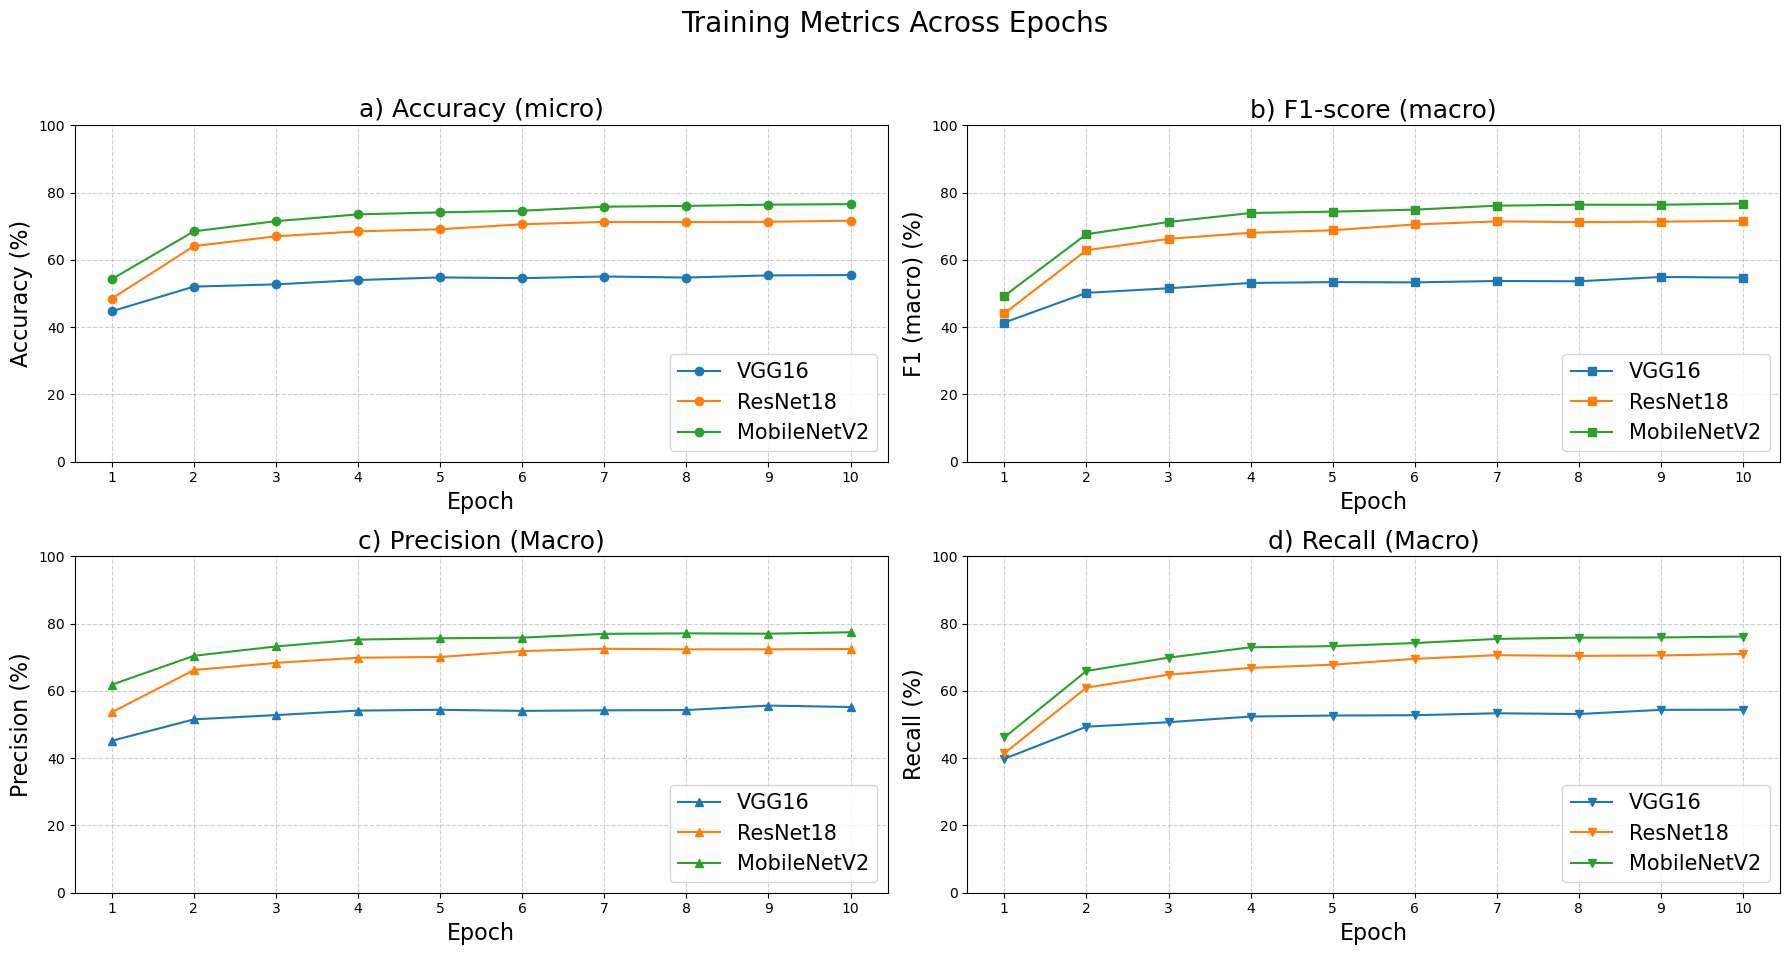

In [120]:
plot_all_metrics_combined(model_train_summaries, train_val="Training")

In [121]:
VGG16_val_summary_full = pd.read_csv('mobilenetv2/vgg16_val_summary1_10.csv')

In [122]:
VGG16_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = VGG16_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [123]:
ResNet18_val_summary_full = pd.read_csv('mobilenetv2/resnet18_val_summary1_10.csv')
ResNet18_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = ResNet18_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [124]:
MobileNetV2_val_summary_1_5 = pd.read_csv('mobilenetv2/mobilenet_v2_val_summary1_5.csv')
MobileNetV2_val_summary_6_10 = pd.read_csv('mobilenetv2/mobilenet_v2_val_summary6_10.csv')
MobileNetV2_val_summary_full = pd.concat([MobileNetV2_val_summary_1_5, MobileNetV2_val_summary_6_10], ignore_index=True)
MobileNetV2_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = MobileNetV2_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [125]:
model_val_summaries = {
    "VGG16": VGG16_val_summary_full,
    "ResNet18": ResNet18_val_summary_full,
    "MobileNetV2": MobileNetV2_val_summary_full
}

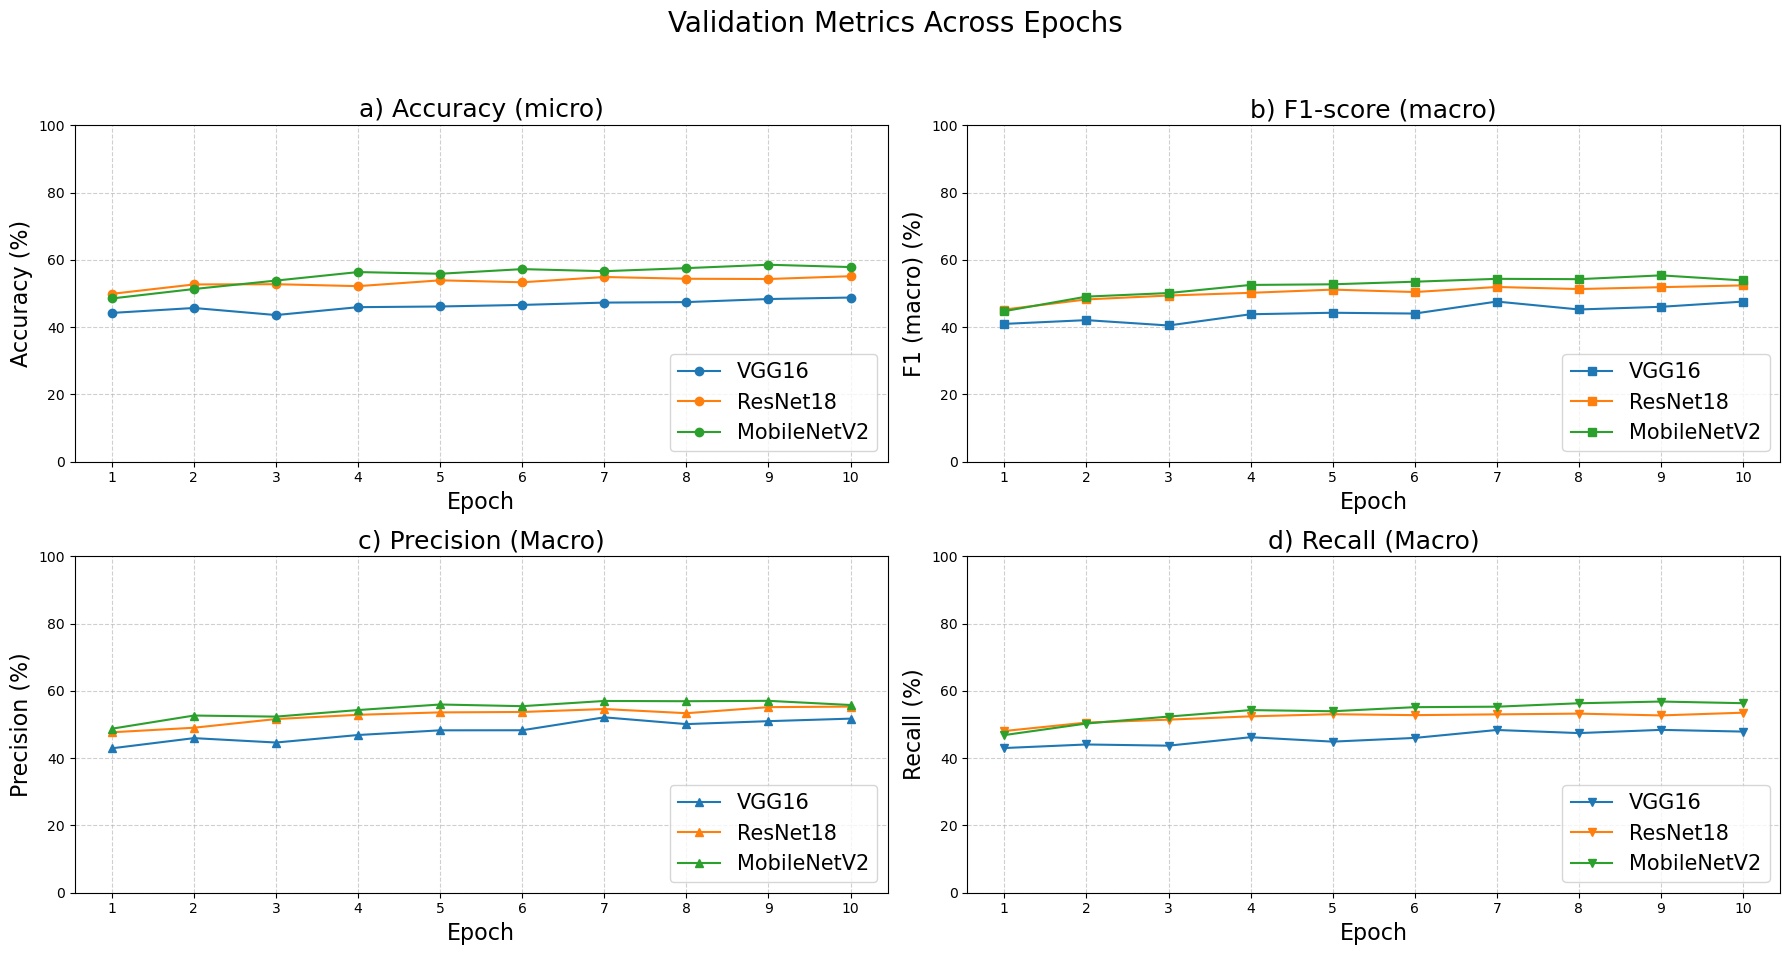

In [126]:
plot_all_metrics_combined(model_val_summaries, train_val="Validation")

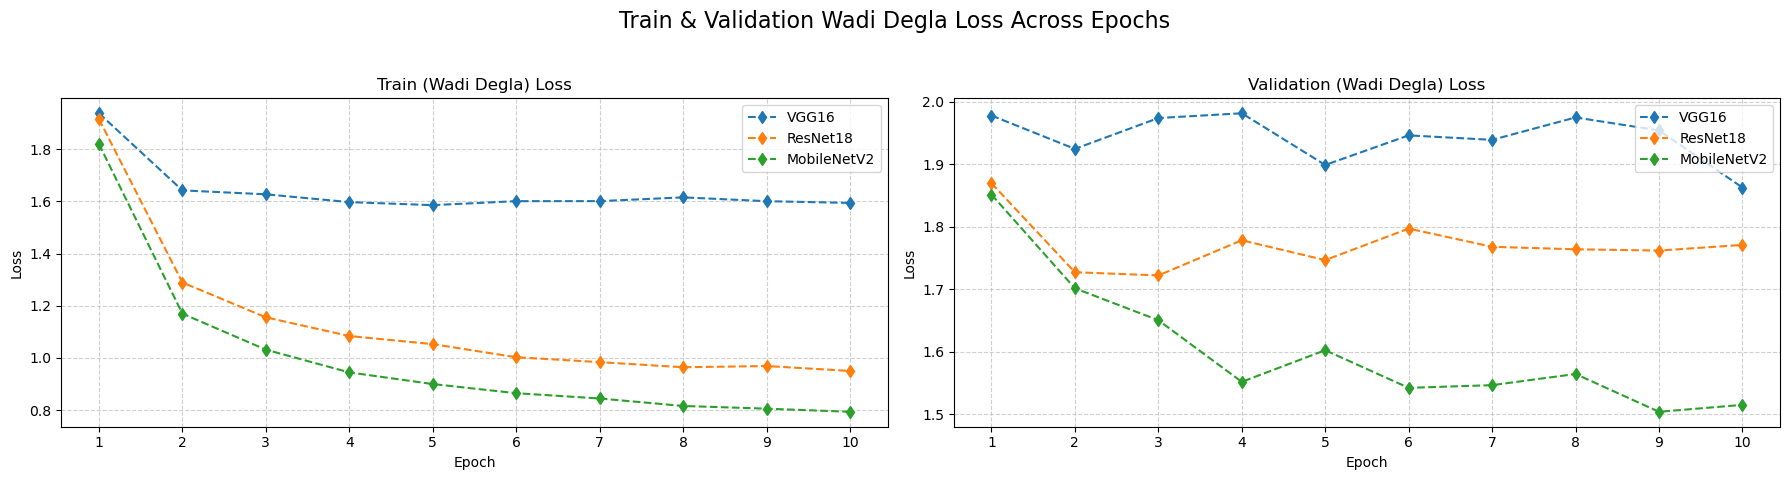

In [127]:
plot_loss(model_train_summaries, model_val_summaries)

| Feature                     | VGG16                              | ResNet-18                           | MobileNetV2                         |
|----------------------------|------------------------------------|-------------------------------------|--------------------------------------|
| **Train Accuracy (%)**     | 55.50                              |             71.66                   | 76.57                                |
| **Validation Accuracy (%)**      | 48.81                              | 55.15                               | 57.87                                |
| **Architecture Type**      | Convolutional (very deep)          | Residual (skip connections)         | Depthwise Separable Convolutions     |
| **Model Size**             | ~537.6 MB                          | ~44.9 MB                            | ~9.3 MB                              |
| **Parameters**             | ~134.40 million                     | ~11.19 million                     | ~2.27 million                        |

In [130]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_validation_bars(
    train_summaries,
    val_summaries,
    epoch
):
    """
    Compare model performance (Train vs Validation) at a specific epoch using side-by-side bar charts.

    Args:
        train_summaries (dict): {model_name: pandas.DataFrame} for training metrics.
        val_summaries (dict): {model_name: pandas.DataFrame} for Validation metrics.
        epoch (int): epoch number to visualize.
    """
    metrics = ['Accuracy (micro)', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)']
    metric_labels = ['Accuracy', 'F1-score', 'Precision', 'Recall']

    def extract_metrics(models_summaries_dict):
        model_names = list(models_summaries_dict.keys())
        values = {model: [] for model in model_names}

        for model_name, df in models_summaries_dict.items():
            if epoch not in df['Epoch'].values:
                print(f"⚠️ Warning: Epoch {epoch} not found for {model_name}, skipping.")
                model_names.remove(model_name)
                continue
            row = df[df['Epoch'] == epoch].iloc[0]
            values[model_name] = [row[m] for m in metrics]
        return model_names, values

    train_models, train_values = extract_metrics(train_summaries)
    val_models, val_values = extract_metrics(val_summaries)

    x = np.arange(len(metrics))
    bar_width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(f'Model Comparison at Epoch {epoch}', fontsize=16)

    # ---------- Helper function ----------
    def plot_one(ax, data_values, model_names, title):
        for i, model_name in enumerate(model_names):
            offset = (i - len(model_names) / 2) * bar_width + bar_width / 2
            ax.bar(x + offset, data_values[model_name], width=bar_width, label=model_name)

        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Metric')
        ax.set_ylabel('Score (%)')
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # ---------- Plot train and val ----------
    plot_one(axes[0], train_values, train_models, "Training Metrics")
    plot_one(axes[1], val_values, val_models, "Validation Metrics")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'Metrics_Comparison_Epoch_{epoch}.png', dpi=300, bbox_inches='tight')
    plt.show()

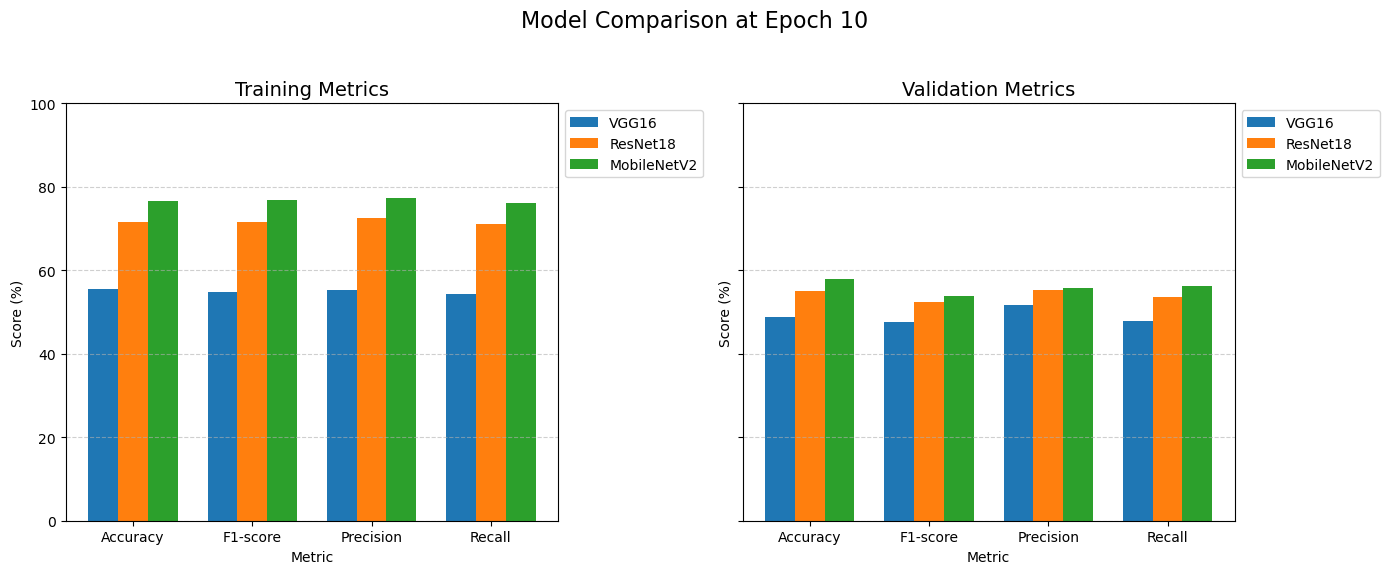

In [131]:
plot_train_validation_bars(model_train_summaries, model_val_summaries, epoch=10)